# Assignment: K Nearest Neighbors on Wine Classification

## Objective

In this assignment, you will use K Nearest Neighbors (KNN) to classify wine samples into different wine classes.

You will practice:

- Loading and inspecting a classification dataset
- Training KNN without scaling
- Training KNN with scaling
- Choosing the value of \(K\)
- Comparing distance metrics
- Using distance-weighted KNN
- Using KNN imputation for missing values

This is a lightweight assignment. Focus on correct implementation and clear interpretation.

## Dataset

We will use the built-in Wine dataset from scikit-learn.

The dataset contains chemical measurements of wine samples. The target is the wine class.

This is a **multiclass classification problem**.

## 1. Setup

Run the install cell only if any package is missing.

In [ ]:
# Run this only if required.
# %pip install numpy pandas matplotlib seaborn scikit-learn

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the Dataset

Load the Wine dataset using `load_wine(as_frame=True)`.

In [3]:
# TODO: Load the wine dataset.
# Hint: use load_wine(as_frame=True)
df = load_wine(as_frame=True)

#raise NotImplementedError("Load the wine dataset")


In [4]:
df.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [5]:
df['data']

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [6]:
# TODO: Create X and y.
# Hint:
# - X should contain the feature DataFrame.
# - y should contain the target values.
X = df['data']
y = df['target']

#raise NotImplementedError("Create X and y")

In [8]:
# TODO: Display the first 5 rows of X and check the shape of X.
X.head()
#raise NotImplementedError("Inspect the dataset")

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [9]:
X.shape

(178, 13)

## 3. Check Class Distribution

Before training a classification model, check how many samples belong to each class.

In [10]:
# TODO: Show count and percentage distribution of y.
# Hint: use value_counts() and value_counts(normalize=True)
y.value_counts(), y.value_counts(normalize=True)

#raise NotImplementedError("Check class distribution")

(target
 1    71
 0    59
 2    48
 Name: count, dtype: int64,
 target
 1    0.398876
 0    0.331461
 2    0.269663
 Name: proportion, dtype: float64)

### Question 1

Is the Wine dataset heavily imbalanced? Why or why not?

Write your answer here:

- All three classes are represented in substantial numbers and reasonable ratios (~40% : 33% : 27%), with no single class severely dominating or suffering from extreme minority representation.

## 4. Train-Test Split

Use a stratified split so each wine class keeps a similar proportion in train and test data.

In [11]:
# TODO: Split X and y into training and test sets.
# Use test_size=0.2, random_state=RANDOM_STATE, and stratify=y.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

#raise NotImplementedError("Create stratified train-test split")

In [12]:
# TODO: Check class distribution in y_train and y_test.
y_train.value_counts(normalize=True), y_test.value_counts(normalize = True)
#raise NotImplementedError("Check train-test class distribution")

(target
 1    0.401408
 0    0.330986
 2    0.267606
 Name: proportion, dtype: float64,
 target
 1    0.388889
 0    0.333333
 2    0.277778
 Name: proportion, dtype: float64)

## 5. Baseline KNN Without Scaling

Train a KNN classifier without scaling.

Use:

```python
KNeighborsClassifier(n_neighbors=5)
```

This model is intentionally incomplete from a best-practice point of view. We will compare it with scaled KNN next.

In [13]:
# TODO: Create and train a KNN model without scaling.
# TODO: Predict on X_test.
# Store predictions in y_pred_no_scaling.

baseline_knn = KNeighborsClassifier(n_neighbors=5)
baseline_knn.fit(X_train, y_train)
y_pred_no_scaling = baseline_knn.predict(X_test)

#raise NotImplementedError("Train KNN without scaling")

### Helper Function to plot confusion matrix

In [15]:
def show_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No Purchase", "Purchase"],
        yticklabels=["No Purchase", "Purchase"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [14]:
# TODO: Print accuracy and classification report for the no-scaling model.
# TODO: Plot a confusion matrix.
print(accuracy_score(y_test, y_pred_no_scaling))
print(classification_report(y_test, y_pred_no_scaling))
#print(confusion_matrix(y_test, y_pred_no_scaling))
#raise NotImplementedError("Evaluate KNN without scaling")

0.8055555555555556
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.77      0.71      0.74        14
           2       0.64      0.70      0.67        10

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.81      0.81      0.81        36

[[12  0  0]
 [ 0 10  4]
 [ 0  3  7]]


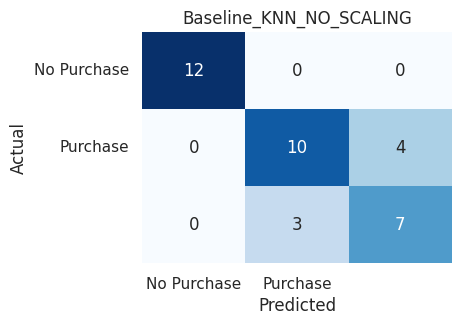

In [16]:
show_confusion_matrix(y_test, y_pred_no_scaling, "Baseline_KNN_NO_SCALING")

## 6. KNN With Scaling

KNN is distance-based, so feature scaling is very important.

For standard scaling:

\[
x_j^{scaled}=\frac{x_j-\mu_j}{\sigma_j}
\]

Use a pipeline:

```text
StandardScaler -> KNeighborsClassifier
```

In [17]:
# TODO: Create a pipeline with StandardScaler and KNeighborsClassifier(n_neighbors=5).
# TODO: Train the pipeline on X_train and y_train.
# TODO: Predict on X_test.
# Store predictions in y_pred_scaled.

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
pipeline.fit(X_train, y_train)
y_pred_scaled = pipeline.predict(X_test)

#raise NotImplementedError("Train KNN with scaling")

In [18]:
# TODO: Print accuracy and classification report for the scaled model.
# TODO: Plot a confusion matrix.
print(accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))


#raise NotImplementedError("Evaluate KNN with scaling")

0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



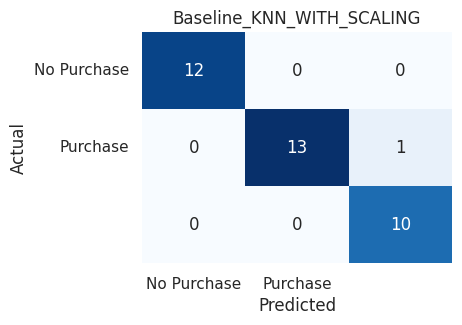

In [19]:
show_confusion_matrix(y_test, y_pred_scaled, "Baseline_KNN_WITH_SCALING")

### Question 2

Did scaling improve the model performance? Explain why scaling matters for KNN.

Write your answer here:

- Yes, feature scaling significantly improved the model's performance from 80% to 97% because K-Nearest Neighbors relies on distance metrics like Euclidean distance to determine similarity. Without scaling, features with larger numerical ranges dominate the distance calculations and distort the model's decision boundary; using StandardScaler places all features on a uniform scale with a mean of 0 and standard deviation of 1, allowing each variable to contribute equally to the distance calculation.

## 7. Choose the Value of \(K\)

Try multiple values of \(K\):

```python
[1, 3, 5, 7, 9, 11, 15]
```

Use cross-validation on the training data.

In [20]:
k_values = [1, 3, 5, 7, 9, 11, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# TODO: For each K, create a scaled KNN pipeline.
# TODO: Use cross_val_score on training data.
# TODO: Store mean CV accuracy for each K in a DataFrame.

cv_scores = []

for k in k_values:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    # Computing cross-validation scores on training data
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    # Append mean score for current K
    cv_scores.append({
        'K': k,
        'mean_accuracy': scores.mean()
    })

# Store results in a DataFrame
results_df = pd.DataFrame(cv_scores)
print(results_df)

    K  mean_accuracy
0   1       0.922660
1   3       0.936946
2   5       0.950739
3   7       0.957882
4   9       0.950739
5  11       0.957882
6  15       0.957882


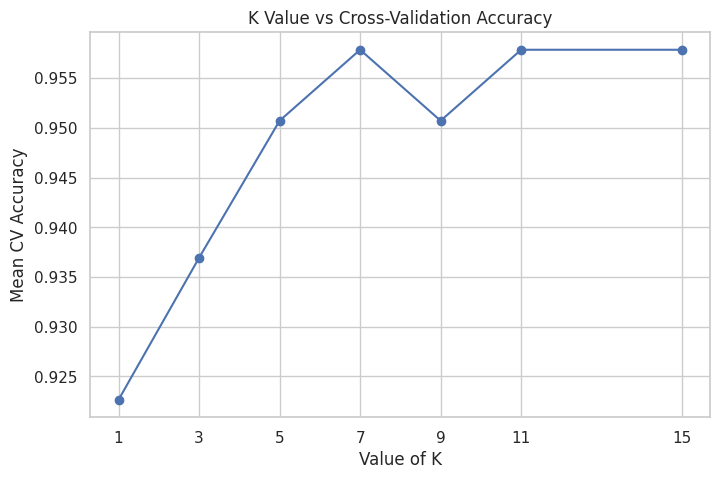

In [21]:
# TODO: Plot K vs cross-validation accuracy.
# TODO: Choose the best K based on CV accuracy.
# Store your selected value in best_k.
# Plot K vs cross-validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(results_df['K'], results_df['mean_accuracy'], marker='o', linestyle='-', color='b')
plt.title('K Value vs Cross-Validation Accuracy')
plt.xlabel('Value of K')
plt.ylabel('Mean CV Accuracy')
plt.xticks(results_df['K'])
plt.grid(True)
plt.show()

# Select best K based on highest CV accuracy
best_k = 7

### Question 3

What can happen when \(K=1\)? What can happen when \(K\) is very large?

Write your answer here:

- When $K=1$, the model has high variance and low bias, leading to overfitting because the decision boundary is overly complex and highly sensitive to noise in the training data. Conversely, when $K$ is very large, the model has high bias and low variance, leading to underfitting because it over-smooths the decision boundary, ignores local feature patterns, and defaults to predicting the majority class across large regions of the data.

## 8. Compare Distance Metrics

Compare KNN with:

- Euclidean distance
- Manhattan distance

Use your selected `best_k` and scaling.

In [22]:
# TODO: Compare metric="euclidean" and metric="manhattan" using cross-validation.
# TODO: Store results in a DataFrame.
metrics = ['euclidean', 'manhattan']
metric_scores = []

for metric in metrics:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k, metric=metric))
    ])

    # Compute cross-validation scores for the current metric
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    # Append mean accuracy score
    metric_scores.append({
        'metric': metric,
        'mean_accuracy': scores.mean()
    })

# Store results in a DataFrame
metrics_df = pd.DataFrame(metric_scores)
print(metrics_df)

      metric  mean_accuracy
0  euclidean       0.957882
1  manhattan       0.978818


### Question 4

Which distance metric performed better? Was the difference large or small?

Write your answer here:

- Manhattan distance performed better, achieving a mean cross-validation accuracy of ~97.88% compared to ~95.79% for Euclidean distance. The performance difference is relatively small—around a 2.1 percentage point increase—indicating that while grid-based distance measuring (L1 norm) aligns slightly better with the spatial feature relationships in this dataset, both metrics yield high overall accuracy.

## 9. Distance-Weighted KNN

In normal KNN, all neighbors vote equally.

In distance-weighted KNN, closer neighbors get more importance.

Compare:

```python
weights="uniform"
weights="distance"
```

In [23]:
# TODO: Compare weights="uniform" and weights="distance" using cross-validation.
# Use best_k, scaling, and your preferred distance metric.
# Store results in a DataFrame.

weight_options = ['uniform', 'distance']
weight_scores = []

for weight in weight_options:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k, metric='manhattan', weights=weight))
    ])

    # Compute cross-validation scores for the current weighting scheme
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    # Append mean accuracy score
    weight_scores.append({
        'weights': weight,
        'mean_accuracy': scores.mean()
    })

# Store results in a DataFrame
weights_df = pd.DataFrame(weight_scores)
print(weights_df)


#raise NotImplementedError("Compare uniform and distance-weighted KNN")

    weights  mean_accuracy
0   uniform       0.978818
1  distance       0.978818


### Question 5

When might distance-weighted KNN be better than uniform voting?

Write your answer here:

- Distance-weighted KNN is typically better than uniform voting when datasets have uneven point density, class imbalances, or larger values of $K$. In uniform voting, every neighbor receives equal influence regardless of distance, which allows far-away neighbors to drown out very close, highly relevant points; distance-weighting solves this by assigning higher weight to closer neighbors, ensuring that local cluster structure dominates the decision boundary even in sparse or noisy regions.

## 10. Final KNN Model

Train your final model using:

- Scaling
- Selected \(K\)
- Selected distance metric
- Selected weighting method

Evaluate on the test data only once after making your choices.

In [24]:
# TODO: Create your final KNN pipeline.
# TODO: Train it on X_train and y_train.
# TODO: Predict on X_test.
# TODO: Report accuracy, classification report, and confusion matrix.
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, metric='manhattan', weights='distance'))
])
final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)

print(accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))
#raise NotImplementedError("Train and evaluate final KNN model")

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



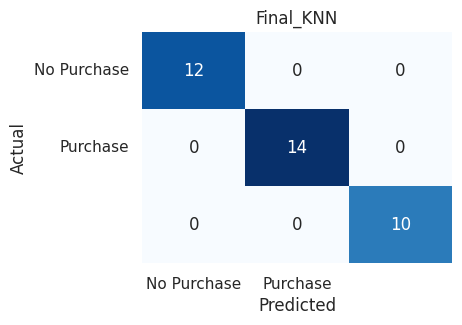

In [25]:
show_confusion_matrix(y_test, y_pred_final, "Final_KNN")

## 11. Mini Task: KNN Imputation

KNN can also be used to fill missing values using similar rows.

In this section, you will create a small amount of missing data and use `KNNImputer`.

In [26]:
X_missing = X.copy()

# This randomly makes around 5% of values missing.
rng = np.random.default_rng(RANDOM_STATE)
missing_mask = rng.random(X_missing.shape) < 0.05
X_missing = X_missing.mask(missing_mask)

# Check missing values per column.
X_missing.isna().sum().sort_values(ascending=False).head(10)

,0
magnesium,12
proanthocyanins,12
nonflavanoid_phenols,11
color_intensity,10
alcalinity_of_ash,9
od280/od315_of_diluted_wines,9
total_phenols,8
alcohol,7
ash,7
malic_acid,7


In [27]:
# TODO: Use KNNImputer to fill missing values.
# Hint:
# - Create KNNImputer with a small number of neighbors, for example 3 or 5.
# - Fit and transform X_missing.
# - Convert the result back into a DataFrame with the same column names.

imputer = KNNImputer(n_neighbors=5)

X_imputed_array = imputer.fit_transform(X_missing)
X_imputed = pd.DataFrame(X_imputed_array, columns=X_missing.columns)

#raise NotImplementedError("Apply KNN imputation")

In [28]:
# TODO: Verify that there are no missing values left after imputation.

print(X_imputed.isnull().sum())

#raise NotImplementedError("Check missing values after KNN imputation")

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


### Question 6

Why can scaling matter before KNN imputation?

Write your answer here:

- Scaling is crucial before KNN imputation because the algorithm relies on distance metrics, such as Euclidean distance, to find the most similar samples to the one with missing data. If features are left unscaled, variables with large numerical ranges will disproportionately dominate the distance calculations, causing the imputer to effectively ignore features with smaller ranges. Standardizing the data first ensures that all features contribute equally to the distance computation, allowing the imputer to find the true nearest neighbors and generate more accurate, unbiased replacement values.

## 12. Final Reflection Questions

Answer briefly.

### Question 7

What does a trained KNN model store?

Answer:

- A trained KNN model is a non-parametric "lazy learner," meaning it does not learn mathematical parameters or explicit weights during training. Instead, it simply stores the entire training dataset (all feature vectors and their corresponding target labels) directly in memory.

### Question 8

Why can KNN become slow when the dataset becomes very large?

Answer:

-KNN becomes slow on large datasets because it defers all computations to prediction time. For every new sample being evaluated, the model must calculate the distance to every single stored training point, sort those distances, and extract the top K neighbors, leading to high computational complexity O(N⋅D) and heavy memory overhead as the dataset size grows.

### Question 9

Which final KNN configuration did you choose, and why?

Mention:

- \(K\)
- Distance metric
- Uniform or distance-weighted voting
- Final test accuracy

Answer:

- K = 7, Distance Metric was Manhattan & chose distance-weighted metric. because I they had the best metrics in the classification report when compared with their alternatives. So using these values my Final Test Accuracy was 1.0

## Submission Checklist

Submit your completed notebook with:

- All code cells executed
- K comparison table or plot
- Distance metric comparison
- Uniform vs distance-weighted comparison
- Final model evaluation
- KNN imputation result
- Answers to all questions